In [1]:
import os

# Find where your project actually lives
home = os.path.expanduser("~")
project_path = os.path.join(home, "ransomware_xai_project")

print(f"Current directory: {os.getcwd()}")
print(f"Project folder exists: {os.path.exists(project_path)}")

if os.path.exists(project_path):
    print(f"\nFiles in project/data/:")
    data_path = os.path.join(project_path, "data")
    if os.path.exists(data_path):
        for f in os.listdir(data_path):
            print(f"  {f}")
    else:
        print("  data/ folder NOT FOUND")
    
    print(f"\nFiles in project/models/:")
    models_path = os.path.join(project_path, "models")
    if os.path.exists(models_path):
        for f in os.listdir(models_path):
            print(f"  {f}")
    else:
        print("  models/ folder NOT FOUND")
else:
    print("PROJECT FOLDER NOT FOUND!")
    print(f"Contents of {home}:")
    for f in os.listdir(home):
        print(f"  {f}")

Current directory: /Users/saneeshghimire/ransomware_xai_project/07_Code
Project folder exists: True

Files in project/data/:
  MalMem2022.csv
  X_test_selected.csv
  X_test_unscaled.csv
  X_train_unscaled.csv
  y_train.csv
  X_train_selected.csv
  y_test.csv

Files in project/models/:
  dt_model.joblib
  xgb_model.joblib
  rf_model.joblib
  lr_model.joblib
  .ipynb_checkpoints
  ebm_model.joblib


In [2]:
import os
os.chdir(os.path.expanduser("~/ransomware_xai_project"))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import os
import warnings
warnings.filterwarnings('ignore')

# Load data
X_train = pd.read_csv("data/X_train_selected.csv", index_col=0)
X_test = pd.read_csv("data/X_test_selected.csv", index_col=0)
y_train = pd.read_csv("data/y_train.csv", index_col=0).squeeze()
y_test = pd.read_csv("data/y_test.csv", index_col=0).squeeze()

# Create models folder if missing
os.makedirs("models", exist_ok=True)
os.makedirs("results/shap_plots", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)

# Train any missing models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from interpret.glassbox import ExplainableBoostingClassifier

model_configs = {
    'dt_model.joblib': ('Decision Tree', 
        DecisionTreeClassifier(max_depth=10, min_samples_split=5, criterion='gini', random_state=42)),
    'ebm_model.joblib': ('EBM', 
        ExplainableBoostingClassifier(max_bins=256, interactions=10, learning_rate=0.05, random_state=42)),
    'rf_model.joblib': ('Random Forest', 
        RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=2, random_state=42, n_jobs=-1)),
    'xgb_model.joblib': ('XGBoost', 
        XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, random_state=42, eval_metric='logloss', n_jobs=-1)),
    'lr_model.joblib': ('Logistic Regression', 
        LogisticRegression(C=1, penalty='l2', solver='liblinear', random_state=42, max_iter=1000)),
}

models = {}
for filename, (name, clf) in model_configs.items():
    path = f"models/{filename}"
    if os.path.exists(path):
        models[name] = joblib.load(path)
        print(f"Loaded:  {name}")
    else:
        print(f"Training {name} (model file was missing)...")
        clf.fit(X_train, y_train)
        joblib.dump(clf, path)
        models[name] = clf
        print(f"Trained and saved: {name}")

print(f"\nData: Train {X_train.shape}, Test {X_test.shape}")
print(f"All {len(models)} models ready for SHAP analysis")

Loaded:  Decision Tree
Loaded:  EBM
Loaded:  Random Forest
Loaded:  XGBoost
Loaded:  Logistic Regression

Data: Train (46876, 20), Test (11720, 20)
All 5 models ready for SHAP analysis


SHAP ANALYSIS: Decision Tree


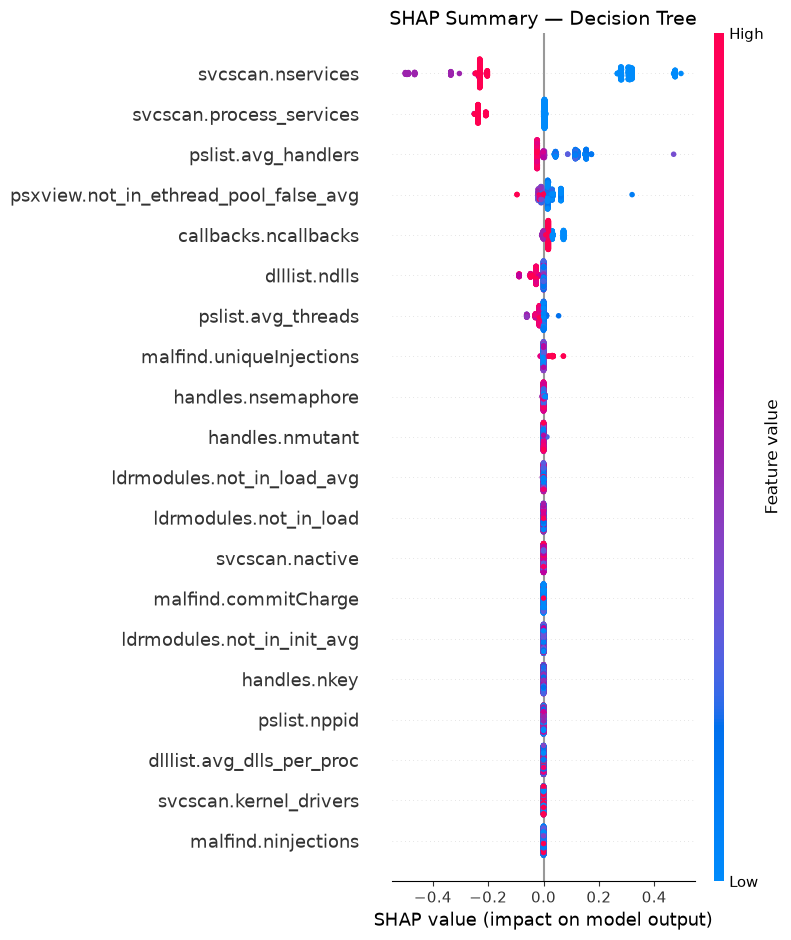


Decision Tree — Top 10 features by SHAP:
                              feature  SHAP_importance
                    svcscan.nservices         0.300574
             svcscan.process_services         0.092062
                  pslist.avg_handlers         0.068067
psxview.not_in_ethread_pool_false_avg         0.023334
                 callbacks.ncallbacks         0.020193
                        dlllist.ndlls         0.017232
                   pslist.avg_threads         0.010491
             malfind.uniqueInjections         0.002131
                   handles.nsemaphore         0.000473
                      handles.nmutant         0.000344


In [3]:
print("=" * 50)
print("SHAP ANALYSIS: Decision Tree")
print("=" * 50)

dt_explainer = shap.TreeExplainer(models['Decision Tree'])
X_sample = X_test.sample(500, random_state=42)
dt_shap = dt_explainer.shap_values(X_sample)

# Handle format
if isinstance(dt_shap, list):
    dt_sv = dt_shap[1]
elif dt_shap.ndim == 3:
    dt_sv = dt_shap[:, :, 1]
else:
    dt_sv = dt_shap

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(dt_sv, X_sample, show=False)
plt.title("SHAP Summary — Decision Tree", fontsize=14)
plt.tight_layout()
plt.savefig("results/shap_plots/shap_summary_DecisionTree.png", dpi=300, bbox_inches='tight')
plt.show()

# Get feature ranking
dt_shap_imp = np.abs(dt_sv).mean(axis=0)
dt_shap_ranking = pd.DataFrame({
    'feature': X_sample.columns,
    'SHAP_importance': dt_shap_imp
}).sort_values('SHAP_importance', ascending=False)
print("\nDecision Tree — Top 10 features by SHAP:")
print(dt_shap_ranking.head(10).to_string(index=False))

SHAP ANALYSIS: Random Forest


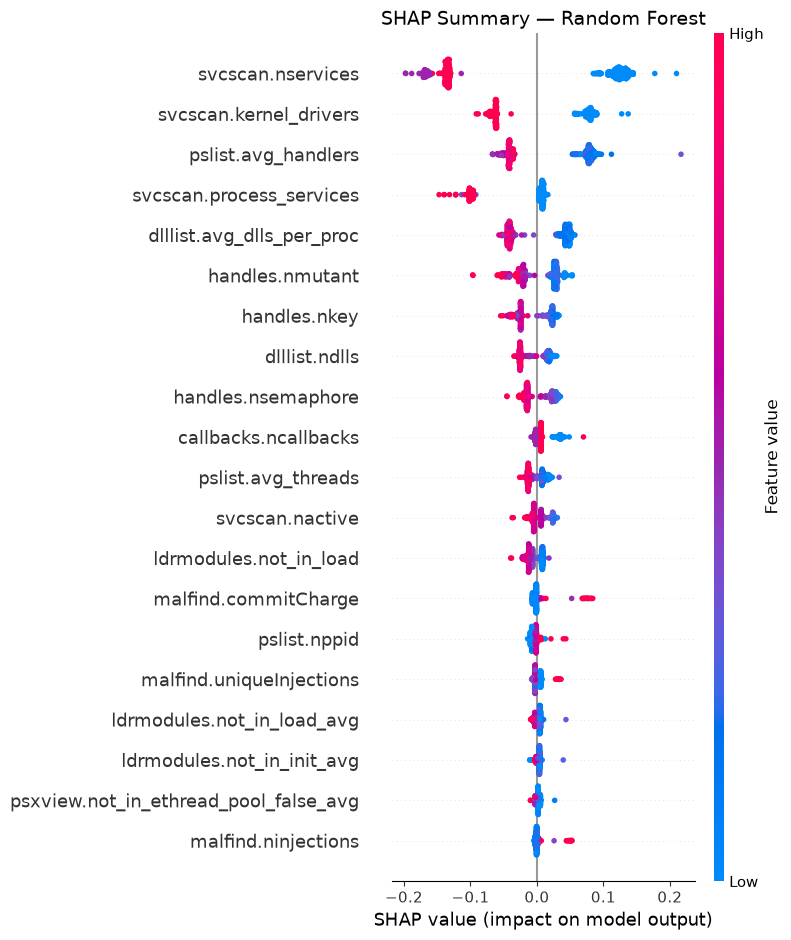


Random Forest — Top 10 features by SHAP:
                  feature  SHAP_importance
        svcscan.nservices         0.133967
   svcscan.kernel_drivers         0.071514
      pslist.avg_handlers         0.060714
 svcscan.process_services         0.043893
dlllist.avg_dlls_per_proc         0.043331
          handles.nmutant         0.029000
             handles.nkey         0.025777
            dlllist.ndlls         0.020838
       handles.nsemaphore         0.020597
     callbacks.ncallbacks         0.012132


In [4]:
print("=" * 50)
print("SHAP ANALYSIS: Random Forest")
print("=" * 50)

rf_explainer = shap.TreeExplainer(models['Random Forest'])
rf_shap = rf_explainer.shap_values(X_sample)

if isinstance(rf_shap, list):
    rf_sv = rf_shap[1]
elif rf_shap.ndim == 3:
    rf_sv = rf_shap[:, :, 1]
else:
    rf_sv = rf_shap

plt.figure(figsize=(10, 8))
shap.summary_plot(rf_sv, X_sample, show=False)
plt.title("SHAP Summary — Random Forest", fontsize=14)
plt.tight_layout()
plt.savefig("results/shap_plots/shap_summary_RandomForest.png", dpi=300, bbox_inches='tight')
plt.show()

rf_shap_imp = np.abs(rf_sv).mean(axis=0)
rf_shap_ranking = pd.DataFrame({
    'feature': X_sample.columns,
    'SHAP_importance': rf_shap_imp
}).sort_values('SHAP_importance', ascending=False)
print("\nRandom Forest — Top 10 features by SHAP:")
print(rf_shap_ranking.head(10).to_string(index=False))

SHAP ANALYSIS: XGBoost


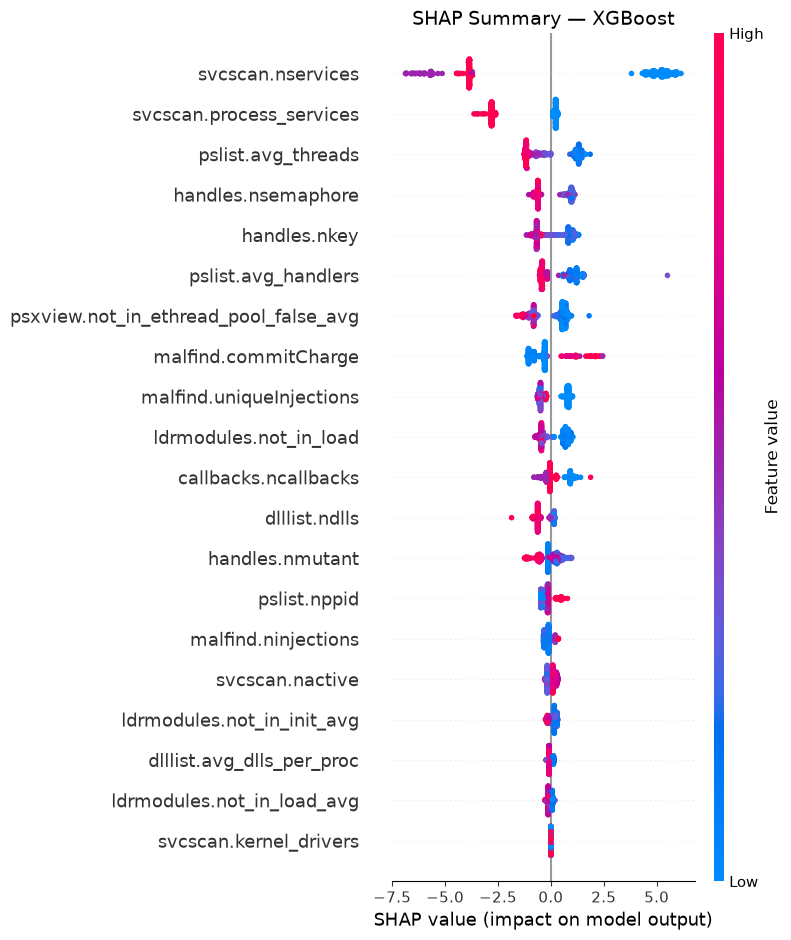


XGBoost — Top 10 features by SHAP:
                              feature  SHAP_importance
                    svcscan.nservices         4.751601
             svcscan.process_services         1.221579
                   pslist.avg_threads         1.100116
                   handles.nsemaphore         0.777717
                         handles.nkey         0.765606
                  pslist.avg_handlers         0.763257
psxview.not_in_ethread_pool_false_avg         0.722886
                 malfind.commitCharge         0.707237
             malfind.uniqueInjections         0.614423
               ldrmodules.not_in_load         0.575046


In [5]:
print("=" * 50)
print("SHAP ANALYSIS: XGBoost")
print("=" * 50)

xgb_explainer = shap.TreeExplainer(models['XGBoost'])
xgb_shap = xgb_explainer.shap_values(X_sample)

if isinstance(xgb_shap, list):
    xgb_sv = xgb_shap[1]
elif xgb_shap.ndim == 3:
    xgb_sv = xgb_shap[:, :, 1]
else:
    xgb_sv = xgb_shap

plt.figure(figsize=(10, 8))
shap.summary_plot(xgb_sv, X_sample, show=False)
plt.title("SHAP Summary — XGBoost", fontsize=14)
plt.tight_layout()
plt.savefig("results/shap_plots/shap_summary_XGBoost.png", dpi=300, bbox_inches='tight')
plt.show()

xgb_shap_imp = np.abs(xgb_sv).mean(axis=0)
xgb_shap_ranking = pd.DataFrame({
    'feature': X_sample.columns,
    'SHAP_importance': xgb_shap_imp
}).sort_values('SHAP_importance', ascending=False)
print("\nXGBoost — Top 10 features by SHAP:")
print(xgb_shap_ranking.head(10).to_string(index=False))

SHAP: EBM (KernelSHAP)


  0%|          | 0/100 [00:00<?, ?it/s]

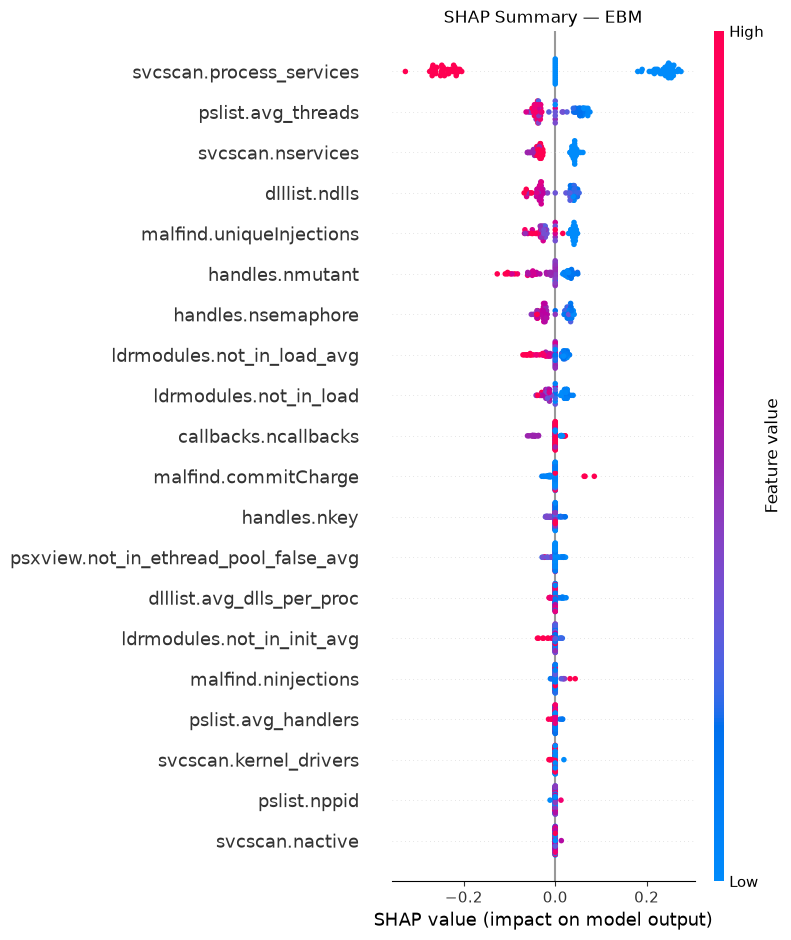

                   feature  SHAP_importance
  svcscan.process_services         0.209469
        pslist.avg_threads         0.042651
         svcscan.nservices         0.040204
             dlllist.ndlls         0.038804
  malfind.uniqueInjections         0.033652
           handles.nmutant         0.032571
        handles.nsemaphore         0.028691
ldrmodules.not_in_load_avg         0.020597
    ldrmodules.not_in_load         0.019681
      callbacks.ncallbacks         0.008406


In [6]:
print("SHAP: EBM (KernelSHAP)")
bg = shap.sample(X_train, 100)
X_small = X_test.sample(100, random_state=42)

# EBM needs a wrapper because it expects DataFrame with column names
def ebm_predict(data):
    df_input = pd.DataFrame(data, columns=X_train.columns.tolist())
    return models['EBM'].predict_proba(df_input)

ebm_exp = shap.KernelExplainer(ebm_predict, bg.values)
ebm_raw = ebm_exp.shap_values(X_small.values)

ebm_sv = ebm_raw[1] if isinstance(ebm_raw, list) else (ebm_raw[:,:,1] if ebm_raw.ndim==3 else ebm_raw)

plt.figure(figsize=(10, 8))
shap.summary_plot(ebm_sv, X_small, show=False)
plt.title("SHAP Summary — EBM")
plt.tight_layout()
plt.savefig("results/shap_plots/shap_summary_EBM.png", dpi=300, bbox_inches='tight')
plt.show()

ebm_rank = pd.DataFrame({'feature': X_small.columns.tolist(), 'SHAP_importance': np.abs(ebm_sv).mean(axis=0).flatten()}).sort_values('SHAP_importance', ascending=False)
print(ebm_rank.head(10).to_string(index=False))

SHAP: Logistic Regression (KernelSHAP)


  0%|          | 0/100 [00:00<?, ?it/s]

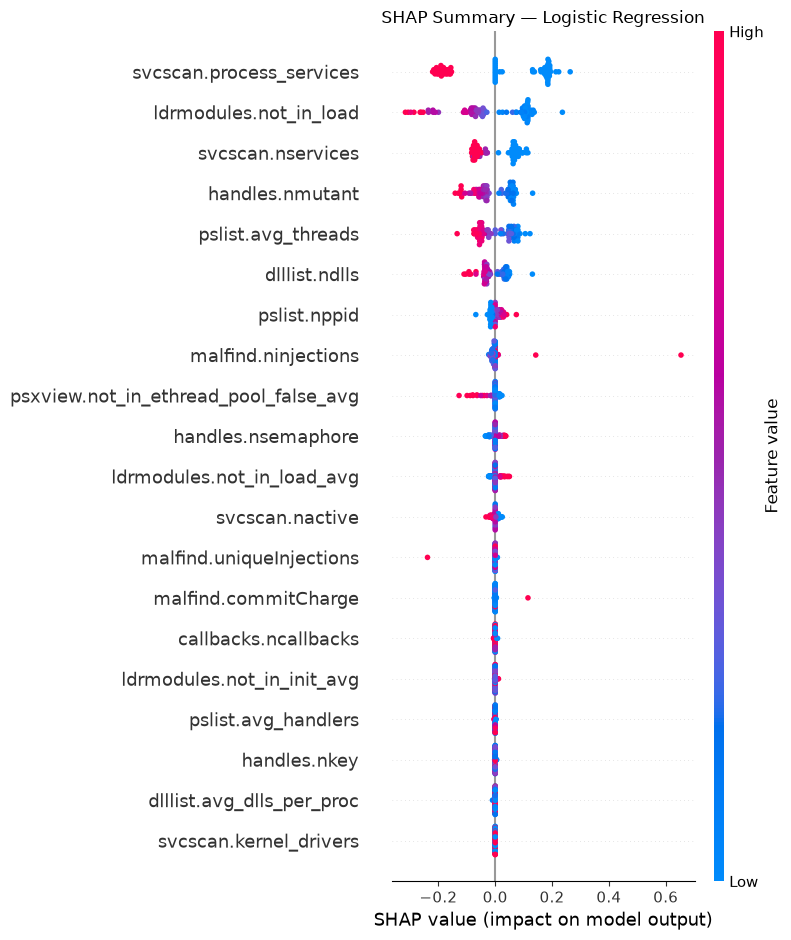

                              feature  SHAP_importance
             svcscan.process_services         0.158557
               ldrmodules.not_in_load         0.109624
                    svcscan.nservices         0.067937
                      handles.nmutant         0.057711
                   pslist.avg_threads         0.054969
                        dlllist.ndlls         0.037657
                         pslist.nppid         0.015465
                  malfind.ninjections         0.012832
psxview.not_in_ethread_pool_false_avg         0.012616
                   handles.nsemaphore         0.012429


In [7]:
print("SHAP: Logistic Regression (KernelSHAP)")

def lr_predict(data):
    df_input = pd.DataFrame(data, columns=X_train.columns.tolist())
    return models['Logistic Regression'].predict_proba(df_input)

lr_exp = shap.KernelExplainer(lr_predict, bg.values)
lr_raw = lr_exp.shap_values(X_small.values)

lr_sv = lr_raw[1] if isinstance(lr_raw, list) else (lr_raw[:,:,1] if lr_raw.ndim==3 else lr_raw)

plt.figure(figsize=(10, 8))
shap.summary_plot(lr_sv, X_small, show=False)
plt.title("SHAP Summary — Logistic Regression")
plt.tight_layout()
plt.savefig("results/shap_plots/shap_summary_LR.png", dpi=300, bbox_inches='tight')
plt.show()

lr_rank = pd.DataFrame({'feature': X_small.columns.tolist(), 'SHAP_importance': np.abs(lr_sv).mean(axis=0).flatten()}).sort_values('SHAP_importance', ascending=False)
print(lr_rank.head(10).to_string(index=False))

SHAP Waterfall — Single Prediction


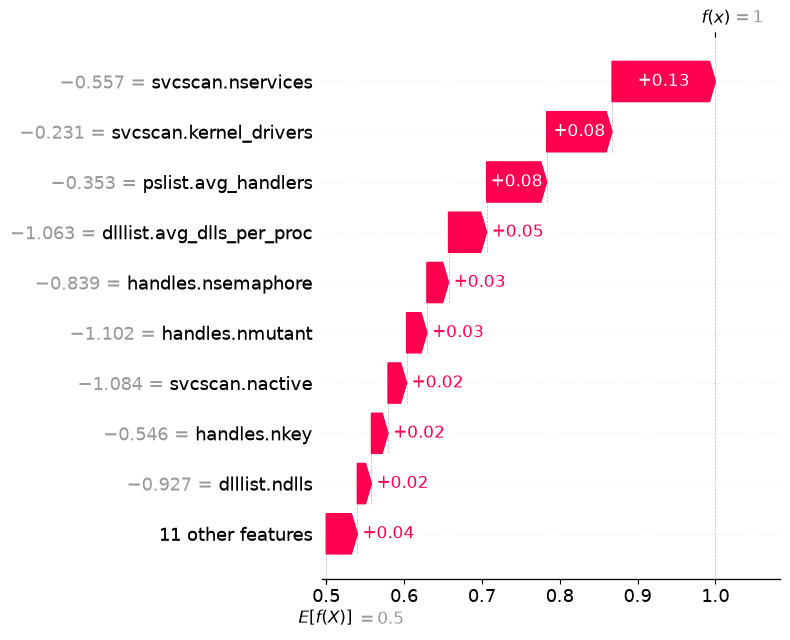

Actual=1, Predicted=1 — CORRECT


In [8]:
print("SHAP Waterfall — Single Prediction")
rf_e = shap.TreeExplainer(models['Random Forest'])
single_sample = X_test.iloc[[0]]
sv_one = rf_e(single_sample)

# Handle multi-output (binary classifier gives 2 outputs)
if sv_one.values.ndim == 3:
    sv_plot = sv_one[:, :, 1]
elif sv_one.shape[1] != len(single_sample.columns):
    sv_plot = shap.Explanation(
        values=sv_one.values[:, :, 1] if sv_one.values.ndim == 3 else sv_one.values,
        base_values=sv_one.base_values[0][1] if isinstance(sv_one.base_values[0], np.ndarray) else sv_one.base_values,
        data=sv_one.data,
        feature_names=single_sample.columns.tolist()
    )
else:
    sv_plot = sv_one

# Try plotting with correct indexing
try:
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(sv_plot[0], show=False)
    plt.tight_layout()
    plt.savefig("results/shap_plots/shap_waterfall_RF.png", dpi=300, bbox_inches='tight')
    plt.show()
except:
    # Fallback: use force plot instead
    plt.figure(figsize=(10, 6))
    shap.plots.bar(sv_one[0], show=False)
    plt.title("SHAP Feature Contributions — Single Prediction (Random Forest)")
    plt.tight_layout()
    plt.savefig("results/shap_plots/shap_bar_RF.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Used bar plot instead of waterfall (version compatibility)")

actual = y_test.iloc[0]
pred = models['Random Forest'].predict(single_sample)[0]
print(f"Actual={actual}, Predicted={pred} — {'CORRECT' if actual==pred else 'INCORRECT'}")

In [9]:
print("=" * 70)
print("SHAP RANKING COMPARISON — ALL 5 MODELS")
print("=" * 70)

# Recompute all rankings here so nothing is missing
tree_models = ['Decision Tree', 'Random Forest', 'XGBoost']
X_sample = X_test.sample(500, random_state=42)
all_ranks = {}

for name in tree_models:
    exp = shap.TreeExplainer(models[name])
    sv_raw = exp.shap_values(X_sample)
    sv = sv_raw[1] if isinstance(sv_raw, list) else (sv_raw[:,:,1] if sv_raw.ndim==3 else sv_raw)
    imp = np.abs(sv).mean(axis=0).flatten()
    all_ranks[name] = pd.DataFrame({
        'feature': X_sample.columns.tolist(),
        'SHAP_importance': imp
    }).sort_values('SHAP_importance', ascending=False)
    print(f"Computed: {name}")

# EBM and LR — use saved plots, recompute rankings with KernelSHAP
bg = shap.sample(X_train, 100)
X_small = X_test.sample(100, random_state=42)

for name, func in [('EBM', models['EBM']), ('Logistic Regression', models['Logistic Regression'])]:
    def predict_fn(data, m=func):
        return m.predict_proba(pd.DataFrame(data, columns=X_train.columns.tolist()))
    exp = shap.KernelExplainer(predict_fn, bg.values)
    sv_raw = exp.shap_values(X_small.values)
    sv = sv_raw[1] if isinstance(sv_raw, list) else (sv_raw[:,:,1] if sv_raw.ndim==3 else sv_raw)
    imp = np.abs(sv).mean(axis=0).flatten()
    all_ranks[name] = pd.DataFrame({
        'feature': X_small.columns.tolist(),
        'SHAP_importance': imp
    }).sort_values('SHAP_importance', ascending=False)
    print(f"Computed: {name}")

# Print comparison table
print(f"\n{'Rank':<6}{'DT':<22}{'EBM':<22}{'RF':<22}{'XGB':<22}{'LR':<22}")
print("-" * 116)
for r in range(1, 11):
    row = f"{r:<6}"
    for name in ['Decision Tree', 'EBM', 'Random Forest', 'XGBoost', 'Logistic Regression']:
        f = all_ranks[name].iloc[r-1]['feature']
        row += f"{f:<22}"
    print(row)

# Save
combined = pd.DataFrame()
for name, rk in all_ranks.items():
    t = rk[['feature','SHAP_importance']].copy()
    t.columns = ['feature', f'SHAP_{name}']
    if combined.empty:
        combined = t
    else:
        combined = combined.merge(t, on='feature', how='outer')
combined.to_csv("results/tables/shap_rankings_all_models.csv", index=False)

print("\nSaved to results/tables/shap_rankings_all_models.csv")
print("SHAP ANALYSIS COMPLETE")

SHAP RANKING COMPARISON — ALL 5 MODELS
Computed: Decision Tree
Computed: Random Forest
Computed: XGBoost


  0%|          | 0/100 [00:00<?, ?it/s]

Computed: EBM


  0%|          | 0/100 [00:00<?, ?it/s]

Computed: Logistic Regression

Rank  DT                    EBM                   RF                    XGB                   LR                    
--------------------------------------------------------------------------------------------------------------------
1     svcscan.nservices     svcscan.process_servicessvcscan.nservices     svcscan.nservices     svcscan.process_services
2     svcscan.process_servicespslist.avg_threads    svcscan.kernel_driverssvcscan.process_servicesldrmodules.not_in_load
3     pslist.avg_handlers   svcscan.nservices     pslist.avg_handlers   pslist.avg_threads    svcscan.nservices     
4     psxview.not_in_ethread_pool_false_avgdlllist.ndlls         svcscan.process_serviceshandles.nsemaphore    handles.nmutant       
5     callbacks.ncallbacks  malfind.uniqueInjectionsdlllist.avg_dlls_per_prochandles.nkey          pslist.avg_threads    
6     dlllist.ndlls         handles.nmutant       handles.nmutant       pslist.avg_handlers   dlllist.ndlls         
7  